# ECG Heartbeat Arrhythmia Classification — Experiment Notebook

Classify single ECG heartbeats (250-sample window + 3 RR-interval features) into four classes:
**Normal, Supraventricular ectopic, Ventricular ectopic, Fusion**. Metric: **Macro F1**.

The notebook is an iterative roadmap, from trivial baselines to a 5-fold ensemble:

| Stage | Model |
|---|---|
| 1 | Dummy baselines |
| 2 | Logistic Regression (class-balanced) |
| 3 | MLP (from scratch) |
| 4 | 1D CNN on the raw signal |
| 5 | Fusion CNN (raw signal + RR features) |
| 6 | Class imbalance: weighted sampler + focal loss |
| 7 | 5-fold stratified CV + soft-vote ensemble |

All models are trained from scratch on the competition data only (no pre-trained weights).
Reusable code lives in [`src/ecg`](../src/ecg); this notebook is the exploratory narrative.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


In [2]:
import os
KAGGLE_DIR = '/kaggle/input/competitions/nppe-2-t-2-26-ecg-heartbeat-arrhythmia-classification/nppe2_dataset'
DATA_DIR = KAGGLE_DIR if os.path.isdir(KAGGLE_DIR) else 'data'   # local runs: put train.csv / test.csv in ./data

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')

sig_cols = [i for i in train.columns if i.startswith('sig_')]
rr_cols = ['pre_rr', 'post_rr', 'rr_ratio']

train.head()

,id,sig_0,sig_1,sig_2,sig_3,sig_4,sig_5,sig_6,sig_7,sig_8,...,sig_244,sig_245,sig_246,sig_247,sig_248,sig_249,pre_rr,post_rr,rr_ratio,label
0,tr_0000000,-0.45936,-0.47194,-0.44595,-0.46766,-0.47848,-0.44212,-0.40911,-0.39630,-0.42572,...,0.34128,0.34599,0.34956,0.34869,0.36385,0.34608,0.620,0.964,0.8378,2
1,tr_0000001,0.46701,0.41676,0.44001,0.46122,0.48141,0.48402,0.48774,0.46058,0.50425,...,0.36419,0.40048,0.40237,0.42921,0.42704,0.44949,1.148,1.128,1.0035,0
2,tr_0000002,-0.05439,-0.06101,-0.03403,-0.04836,-0.09790,-0.12191,-0.16152,-0.18606,-0.17850,...,0.23109,0.07517,-0.02015,-0.13179,-0.17835,-0.23683,0.588,0.580,1.0000,0
3,tr_0000003,0.02038,0.56312,0.93705,0.03558,-1.49486,-2.12957,-2.19772,-1.94957,-1.81099,...,0.36522,0.30252,0.53578,1.37349,2.55773,3.52536,0.496,0.496,1.0164,0
4,tr_0000004,-0.43263,-0.45353,-0.43887,-0.42160,-0.38072,-0.38062,-0.41078,-0.46798,-0.48628,...,-0.18767,-0.19071,-0.11951,-0.14097,-0.18661,-0.26196,0.892,0.896,0.9911,0


(71748, 255)
label
0    45000
1     3599
2    22552
3      597
Name: count, dtype: int64


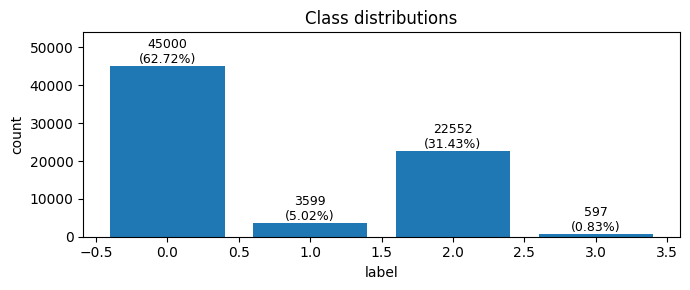

In [3]:
print(train.shape)
counts = train['label'].value_counts().sort_index()
print(counts)

fig, ax = plt.subplots(figsize=(7, 3))

ax.bar(counts.index, counts.values)

ax.set_ylim(0, counts.max() * 1.2)

for i, v in enumerate(counts.values):
    percentage = (v / len(train['label'])) * 100
    text = f"{v}\n({percentage:.2f}%)"
    
    ax.text(i, v + counts.max() * 0.02, text, ha='center', fontsize=9)

ax.set_title('Class distributions')
ax.set_xlabel('label')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

* checking for missing values.

In [4]:
train_na = train.isna().sum()
test_na = test.isna().sum()

print(f"Train dataset missing values: \n{train_na[train_na > 0]}")
print(f'\nTest dataset: \n{test_na[test_na > 0]}')

Train dataset missing values: 
pre_rr       7
post_rr     17
rr_ratio     7
dtype: int64

Test dataset: 
pre_rr      13
post_rr     10
rr_ratio    13
dtype: int64


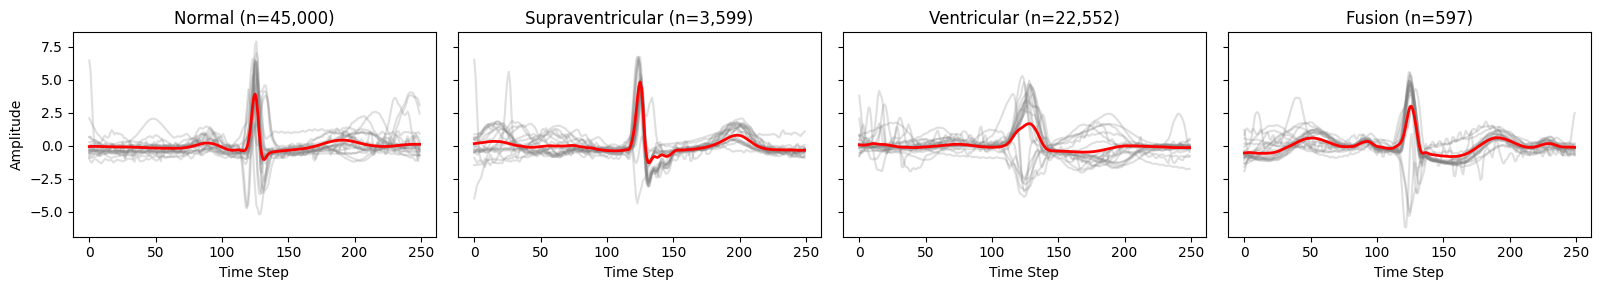

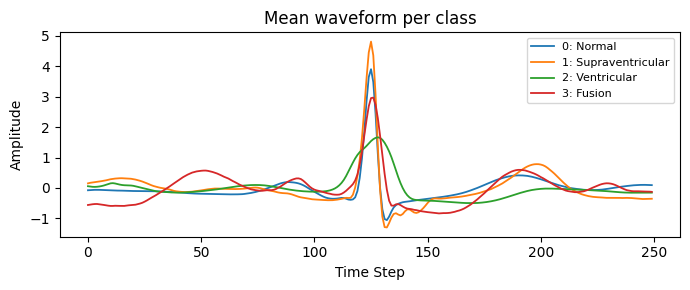

Signal Stats -> Min: -8.542 | Max: 9.071 | Mean: 0.000 | Std: 1.000


In [5]:
# Configuration
NUM_TIMESTEPS = 250
MAX_SAMPLES_TO_PLOT = 20
CLASS_LABELS = {
    0: 'Normal',
    1: 'Supraventricular',
    2: 'Ventricular',
    3: 'Fusion'
}

signal_columns = [f"sig_{i}" for i in range(NUM_TIMESTEPS)]

# 1. Plot individual representative signals & mean profile per class (Subplots)
fig, axes = plt.subplots(1, len(CLASS_LABELS), figsize=(16, 3), sharey=True)

for class_id, class_name in CLASS_LABELS.items():
    class_data = train[train['label'] == class_id][signal_columns]
    sample_size = min(MAX_SAMPLES_TO_PLOT, len(class_data))
    
    # Plot individual representative signals (faint lines)
    sample_signals = class_data.sample(n=sample_size, random_state=0)
    axes[class_id].plot(sample_signals.T.values, color='gray', alpha=0.25)
    
    # Plot class mean signal profile (bold overlay)
    mean_signal = class_data.mean().values
    axes[class_id].plot(mean_signal, color='red', linewidth=2, label='Mean Signal')
    
    axes[class_id].set_title(f"{class_name} (n={len(class_data):,})")
    axes[class_id].set_xlabel("Time Step")

axes[0].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

# 2. Plot average morphology overlay per class (Single Combined Plot)
fig, ax = plt.subplots(figsize=(7, 3))
for class_id, class_name in CLASS_LABELS.items():
    mean_signal = train[train['label'] == class_id][signal_columns].mean().values
    ax.plot(mean_signal, lw=1.3, label=f'{class_id}: {class_name}')

ax.legend(fontsize=8)
ax.set_title('Mean waveform per class')
ax.set_xlabel('Time Step')
ax.set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

# 3. Check signal scale stats
signal_matrix = train[signal_columns].to_numpy()
print(
    f"Signal Stats -> "
    f"Min: {signal_matrix.min():.3f} | "
    f"Max: {signal_matrix.max():.3f} | "
    f"Mean: {signal_matrix.mean():.3f} | "
    f"Std: {signal_matrix.std():.3f}"
)

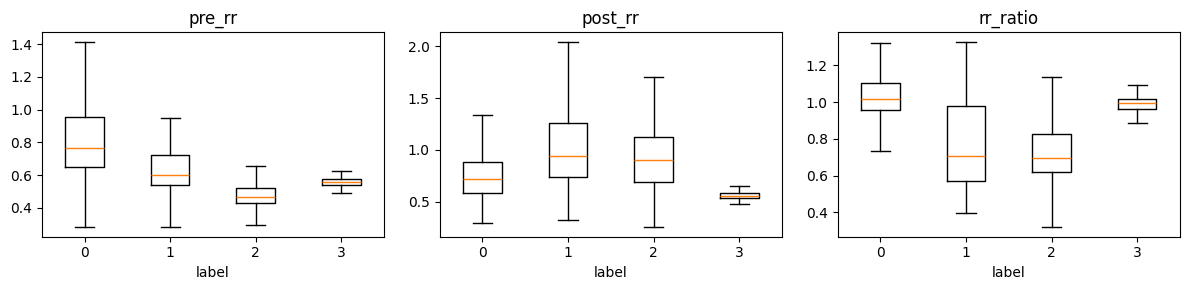

pre_rr        post_rr        rr_ratio       
        mean    std    mean    std     mean    std
label                                             
0      0.813  0.236   0.752  0.227    1.065  0.244
1      0.615  0.112   1.047  0.453    0.762  0.198
2      0.482  0.088   0.901  0.282    0.727  0.152
3      0.593  0.140   0.603  0.146    0.999  0.162

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for k, col in enumerate(rr_cols):
    data_to_plot = [train.loc[train['label'] == c, col].dropna() for c in range(4)]
    
    axes[k].boxplot(data_to_plot, showfliers=False)
    axes[k].set_xticklabels([str(c) for c in range(4)])
    axes[k].set_title(col)
    axes[k].set_xlabel('label')

plt.tight_layout()
plt.show()

display(train.groupby('label')[rr_cols].agg(['mean', 'std']).round(3))

Observations that shape the design:
* Class 3 (Fusion) has only ~0.8% of samples  -> plain accuracy is useless, we need Macro F1.
* Ectopic beats (1 & 2) arrive EARLY (rr_ratio << 1) and class 0 sits near 1.0
  * the three RR numbers alone are strongly predictive.
* Waveform morphology differs between classes too (mean traces above)
  * shape features should disambiguate 1 vs 2 and help rare class 3.


In [7]:
feature_cols = sig_cols + rr_cols
X = train[feature_cols].values
y = train['label'].values

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

dm1 = DummyClassifier(strategy='most_frequent')
dm1.fit(X_tr, y_tr)
val_pred1 = dm1.predict(X_val)

dm2 = DummyClassifier(strategy='stratified')
dm2.fit(X_tr, y_tr)
val_pred2 = dm2.predict(X_val)

dm_f1_mf = f1_score(y_val, val_pred1, average='macro')
dm_f1_strat = f1_score(y_val, val_pred2, average='macro')

print("DummyClassifier/most_frequent Macro f1: ", dm_f1_mf)
print("DummyClassifier/stratified Macro f1: ", dm_f1_strat)
print(f"\n{classification_report(y_val, val_pred1, digits=3)}")
print(f"\n{classification_report(y_val, val_pred2, digits=3)}")

DummyClassifier/most_frequent Macro f1:  0.19271948608137046
DummyClassifier/stratified Macro f1:  0.24832168840797997

              precision    recall  f1-score   support

           0      0.627     1.000     0.771      9000
           1      0.000     0.000     0.000       720
           2      0.000     0.000     0.000      4511
           3      0.000     0.000     0.000       119

    accuracy                          0.627     14350
   macro avg      0.157     0.250     0.193     14350
weighted avg      0.393     0.627     0.483     14350


              precision    recall  f1-score   support

           0      0.628     0.630     0.629      9000
           1      0.031     0.031     0.031       720
           2      0.317     0.316     0.316      4511
           3      0.017     0.017     0.017       119

    accuracy                          0.496     14350
   macro avg      0.248     0.248     0.248     14350
weighted avg      0.495     0.496     0.496     14350



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# ML Baseline

## preprocessing/Imputation in rr_cols

In [8]:
si = SimpleImputer(strategy='median')
X_tr = si.fit_transform(X_tr)
X_val = si.transform(X_val)

In [9]:
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

logreg = LogisticRegression(max_iter=2000, class_weight='balanced')
logreg.fit(X_tr_scaled, y_tr)

val_pred = logreg.predict(X_val_scaled)

f1_lr = f1_score(y_val, val_pred, average='macro')

print("Logistic Regression Macro F1:", f1_lr)
print(classification_report(y_val, val_pred, digits=3))

Logistic Regression Macro F1: 0.7143205142962782
              precision    recall  f1-score   support

           0      0.990     0.884     0.934      9000
           1      0.654     0.932     0.769       720
           2      0.960     0.937     0.948      4511
           3      0.117     0.866     0.206       119

    accuracy                          0.903     14350
   macro avg      0.680     0.905     0.714     14350
weighted avg      0.957     0.903     0.924     14350



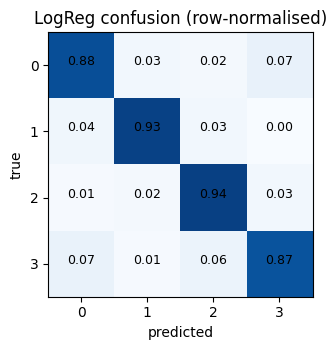

1 · dummy/most_frequent    0.1927
1 · dummy/stratified       0.2483
2 · LogReg (balanced)      0.7143
dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(4.4, 3.6))
cm = confusion_matrix(y_val, val_pred, normalize='true')
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', fontsize=9)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('LogReg confusion (row-normalised)')
plt.tight_layout()
plt.show()

baseline_table = {'1 · dummy/most_frequent': dm_f1_mf,
                  '1 · dummy/stratified'  : dm_f1_strat,
                  '2 · LogReg (balanced)' : f1_lr}
print(pd.Series(baseline_table).round(4))


# MLP-scratch

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time

class ECGDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long) if y is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

def evaluate(model, loader, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in loader:
            inputs = [x.to(device) for x in batch[:-1]]
            yb = batch[-1]            
            logits = model(*inputs)
            preds.extend(logits.argmax(dim=1).cpu().numpy())
            trues.extend(yb.numpy())            
    return f1_score(trues, preds, average='macro')

def train_model(epochs, model, train_loader, val_loader, optimizer, scheduler, criterion, device):
    hist_f1 = []
    t0 = time.time()    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0        
        for batch in train_loader:
            inputs = [x.to(device) for x in batch[:-1]]
            yb = batch[-1].to(device)            
            optimizer.zero_grad()
            logits = model(*inputs)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()            
            if scheduler is not None:
                scheduler.step()                
            total_loss += loss.item() * inputs[0].size(0)
            
        val_f1 = evaluate(model, val_loader, device)
        hist_f1.append(val_f1)        
        print(f"epoch {epoch+1:2d}/{epochs} | train loss {total_loss/len(train_loader.dataset):.4f} | val Macro F1 {val_f1:.4f}")        
    print(f"Training completed in {time.time()-t0:.0f}s | Best Macro-F1: {max(hist_f1):.4f}")
    return hist_f1

def predict(model, loader, device='cuda'):
    model.eval()
    preds, trues = [], []    
    with torch.no_grad():
        for batch in loader:
            inputs = [x.to(device) for x in batch[:-1]]
            yb = batch[-1]
            logits = model(*inputs)
            preds.extend(logits.argmax(dim=1).cpu().numpy())
            trues.extend(yb.numpy())            
    return preds, trues


In [12]:
mlp_X_tr = DataLoader(ECGDataset(X_tr_scaled, y_tr), batch_size=128, shuffle=True)
mlp_X_val = DataLoader(ECGDataset(X_val_scaled, y_val), batch_size=256, shuffle=False)

class SimpleMLP(nn.Module):
    def __init__(self, in_dim, hidden=256, n_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, n_classes),
        )

    def forward(self, x):
        return self.net(x)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SimpleMLP(in_dim=X_tr_scaled.shape[1]).to(device)

print(f'MLP parameters: {sum(p.numel() for p in model.parameters()):,}')

class_counts = np.bincount(y_tr)
class_weights = torch.tensor(len(y_tr) / (len(class_counts) * class_counts), dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, total_steps=20 * len(mlp_X_tr))

hist_mlp = train_model(
    epochs=20,
    model=model,
    train_loader=mlp_X_tr,
    val_loader=mlp_X_val,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    device=device
)

mlp_f1 = max(hist_mlp)

print(f'  MLP best score = {mlp_f1:.4f}')

MLP parameters: 98,436
epoch  1/20 | train loss 0.9428 | val Macro F1 0.6579
epoch  2/20 | train loss 0.3919 | val Macro F1 0.7321
epoch  3/20 | train loss 0.2583 | val Macro F1 0.7115
epoch  4/20 | train loss 0.2423 | val Macro F1 0.7378
epoch  5/20 | train loss 0.2113 | val Macro F1 0.7899
epoch  6/20 | train loss 0.1976 | val Macro F1 0.8009
epoch  7/20 | train loss 0.1778 | val Macro F1 0.8312
epoch  8/20 | train loss 0.1640 | val Macro F1 0.7811
epoch  9/20 | train loss 0.1480 | val Macro F1 0.8127
epoch 10/20 | train loss 0.1348 | val Macro F1 0.8176
epoch 11/20 | train loss 0.1189 | val Macro F1 0.8032
epoch 12/20 | train loss 0.1098 | val Macro F1 0.8460
epoch 13/20 | train loss 0.0941 | val Macro F1 0.8304
epoch 14/20 | train loss 0.0879 | val Macro F1 0.8262
epoch 15/20 | train loss 0.0801 | val Macro F1 0.8446
epoch 16/20 | train loss 0.0679 | val Macro F1 0.8546
epoch 17/20 | train loss 0.0615 | val Macro F1 0.8566
epoch 18/20 | train loss 0.0613 | val Macro F1 0.8572
epoch

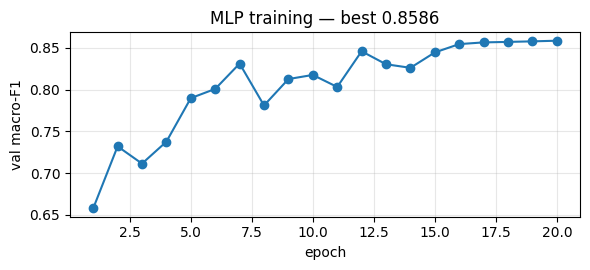

In [13]:
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.plot(range(1, len(hist_mlp) + 1), hist_mlp, marker='o')
ax.set_xlabel('epoch')
ax.set_ylabel('val macro-F1')
ax.set_title(f'MLP training — best {mlp_f1:.4f}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

p_mlp, trues = predict(model, mlp_X_val, device=device)

print(classification_report(trues, p_mlp, digits=3))

# 1D CNN over the raw signal

In [14]:
n_sig = len(sig_cols)
train_loader_cnn = DataLoader(ECGDataset(X_tr_scaled[:, :n_sig], y_tr), batch_size=128, shuffle=True)
val_loader_cnn   = DataLoader(ECGDataset(X_val_scaled[:, :n_sig], y_val), batch_size=256, shuffle=False)

class CNNOnly(nn.Module):
    def __init__(self, in_channels=1, n_classes=4):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),          nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),         nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten())
        self.head = nn.Linear(128, n_classes)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        features = self.cnn(x)
        return self.head(features)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNNOnly(n_classes=4).to(device)

print(f'CNN parameters: {sum(p.numel() for p in model.parameters()):,}')

class_counts = np.bincount(y_tr)
class_weights = torch.tensor(len(y_tr) / (len(class_counts) * class_counts), dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, total_steps=20 * len(train_loader_cnn))

hist_cnn = train_model(epochs=20, model=model, criterion=criterion, optimizer=optimizer, scheduler=scheduler, train_loader=train_loader_cnn, val_loader=val_loader_cnn, device=device)

cnn_f1 = max(hist_cnn)
print(f'  CNN best score={cnn_f1}')

CNN parameters: 36,228
epoch  1/20 | train loss 1.2273 | val Macro F1 0.4253
epoch  2/20 | train loss 0.9513 | val Macro F1 0.5650
epoch  3/20 | train loss 0.7067 | val Macro F1 0.5779
epoch  4/20 | train loss 0.5660 | val Macro F1 0.0680
epoch  5/20 | train loss 0.5054 | val Macro F1 0.4430
epoch  6/20 | train loss 0.4528 | val Macro F1 0.7399
epoch  7/20 | train loss 0.4153 | val Macro F1 0.5151
epoch  8/20 | train loss 0.3709 | val Macro F1 0.7999
epoch  9/20 | train loss 0.3335 | val Macro F1 0.7671
epoch 10/20 | train loss 0.3064 | val Macro F1 0.6635
epoch 11/20 | train loss 0.2773 | val Macro F1 0.5980
epoch 12/20 | train loss 0.2566 | val Macro F1 0.7485
epoch 13/20 | train loss 0.2354 | val Macro F1 0.8243
epoch 14/20 | train loss 0.2131 | val Macro F1 0.7143
epoch 15/20 | train loss 0.1963 | val Macro F1 0.7627
epoch 16/20 | train loss 0.1782 | val Macro F1 0.7324
epoch 17/20 | train loss 0.1707 | val Macro F1 0.7735
epoch 18/20 | train loss 0.1585 | val Macro F1 0.7953
epoch

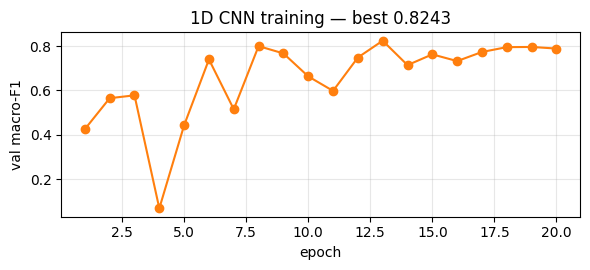

In [15]:
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.plot(range(1, len(hist_cnn) + 1), hist_cnn, marker='o', color='tab:orange')
ax.set_xlabel('epoch')
ax.set_ylabel('val macro-F1')
ax.set_title(f'1D CNN training — best {cnn_f1:.4f}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

p_cnn, trues = predict(model, val_loader_cnn, device=device)

print(classification_report(trues, p_cnn, digits=3))

# Fused CNN: Raw Signal + RR Features

In [16]:
train_loader_fcnn = DataLoader(ECGDataset(X_tr_scaled, y_tr), batch_size=128, shuffle=True)
val_loader_fcnn = DataLoader(ECGDataset(X_val_scaled, y_val), batch_size=256, shuffle=False)

class FusionCNN(nn.Module):
    def __init__(self, n_classes=4, in_channels=1, n_rr=3, head_hidden=64):
        super().__init__()
        self.n_rr = n_rr
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),          nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),         nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), 
            nn.Flatten()
        )
        self.rr = nn.Sequential(nn.Linear(3, 32), nn.ReLU(), nn.Linear(32, 64), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(128 + 64, head_hidden), nn.ReLU(), nn.Dropout(0.30), nn.Linear(head_hidden, n_classes))
        
    def forward(self, x):
        x_sig = x[:, :-self.n_rr]
        x_rr  = x[:, -self.n_rr:]
        if x_sig.dim() == 2:
            x_sig = x_sig.unsqueeze(1)
        sig_feat = self.cnn(x_sig)
        rr_feat  = self.rr(x_rr)
        fusion_feat = torch.cat([sig_feat, rr_feat], dim=1)
        return self.head(fusion_feat)
        
device = 'cuda' if torch.cuda.is_available() else 'cpu'
fusion = FusionCNN(n_classes=4).to(device)

print(f'Fusion Model parameters: {sum(p.numel() for p in fusion.parameters()):,}')

class_counts = np.bincount(y_tr)
class_weights = torch.tensor(len(y_tr) / (len(class_counts) * class_counts), dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(fusion.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, total_steps=20 * len(train_loader_fcnn))

hist_fcnn = train_model(epochs=20, model=fusion, train_loader=train_loader_fcnn, val_loader=val_loader_fcnn, optimizer=optimizer, scheduler=scheduler, criterion=criterion, device=device)

max_f1 = max(hist_fcnn)
print(f" FusionCNN best score={max_f1:.4f}")

Fusion Model parameters: 50,564
epoch  1/20 | train loss 1.2204 | val Macro F1 0.6888
epoch  2/20 | train loss 0.6468 | val Macro F1 0.6149
epoch  3/20 | train loss 0.4266 | val Macro F1 0.7492
epoch  4/20 | train loss 0.3560 | val Macro F1 0.6152
epoch  5/20 | train loss 0.3194 | val Macro F1 0.7260
epoch  6/20 | train loss 0.2888 | val Macro F1 0.7763
epoch  7/20 | train loss 0.2677 | val Macro F1 0.7657
epoch  8/20 | train loss 0.2402 | val Macro F1 0.6727
epoch  9/20 | train loss 0.2126 | val Macro F1 0.7577
epoch 10/20 | train loss 0.1998 | val Macro F1 0.7696
epoch 11/20 | train loss 0.1756 | val Macro F1 0.5880
epoch 12/20 | train loss 0.1669 | val Macro F1 0.7727
epoch 13/20 | train loss 0.1524 | val Macro F1 0.8070
epoch 14/20 | train loss 0.1429 | val Macro F1 0.7996
epoch 15/20 | train loss 0.1158 | val Macro F1 0.8194
epoch 16/20 | train loss 0.1032 | val Macro F1 0.8266
epoch 17/20 | train loss 0.1000 | val Macro F1 0.8256
epoch 18/20 | train loss 0.0945 | val Macro F1 0.8

              precision    recall  f1-score   support

           0      0.996     0.963     0.979      9000
           1      0.843     0.971     0.903       720
           2      0.983     0.975     0.979      4511
           3      0.311     0.891     0.461       119

    accuracy                          0.967     14350
   macro avg      0.783     0.950     0.830     14350
weighted avg      0.978     0.967     0.971     14350



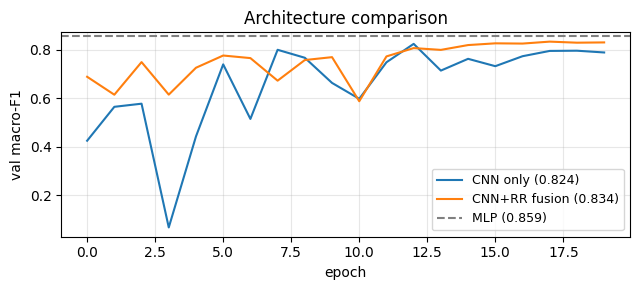

1 · dummy/most_frequent    0.1927
1 · dummy/stratified       0.2483
2 · LogReg (balanced)      0.7143
3 · MLP (from scratch)     0.8586
4 · 1D CNN                 0.8243
5 · CNN+RR fusion          0.8336
dtype: float64


In [17]:
pred, trues = predict(fusion, val_loader_fcnn)
print(classification_report(trues, pred, digits=3))

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(hist_cnn, label=f'CNN only ({cnn_f1:.3f})')
ax.plot(hist_fcnn, label=f'CNN+RR fusion ({max_f1:.3f})')
ax.axhline(mlp_f1, ls='--', c='gray', label=f'MLP ({mlp_f1:.3f})')
ax.set_xlabel('epoch')
ax.set_ylabel('val macro-F1')
ax.legend(fontsize=9)
ax.set_title('Architecture comparison')
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

stage_table = dict(baseline_table)
stage_table.update({'3 · MLP (from scratch)': mlp_f1,
                    '4 · 1D CNN'            : cnn_f1,
                    '5 · CNN+RR fusion'     : max_f1})
print(pd.Series(stage_table).round(4))

# Tackling class imbalance

In [18]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, target):
        ce = nn.functional.cross_entropy(logits, target, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


class_counts = np.bincount(y_tr)
class_weights = torch.tensor(len(y_tr) / (len(class_counts) * class_counts), dtype=torch.float32).to(device)

# per-sample weight = inverse frequency of that sample's class
sample_weights = class_weights.cpu()[torch.tensor(y_tr)].numpy()
sampler = torch.utils.data.WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# validation loader is UNTOUCHED — leaderboard sees the real class distribution, so val must too
train_loader_bal = DataLoader(ECGDataset(X_tr_scaled, y_tr), batch_size=128, sampler=sampler)

fusion_bal = FusionCNN(n_classes=4).to(device)
focal = FocalLoss(alpha=class_weights, gamma=2.0)

optimizer = torch.optim.AdamW(fusion_bal.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, total_steps=20 * len(train_loader_bal))

hist_bal = train_model(epochs=20, model=fusion_bal, train_loader=train_loader_bal, val_loader=val_loader_fcnn,
                  optimizer=optimizer, scheduler=scheduler, criterion=focal, device=device)

bal_f1 = max(hist_bal)
print(f'Sampler + Focal FusionCNN best score={bal_f1:.4f}')

epoch  1/20 | train loss 6.3932 | val Macro F1 0.0805
epoch  2/20 | train loss 1.3328 | val Macro F1 0.1838
epoch  3/20 | train loss 0.5863 | val Macro F1 0.2840
epoch  4/20 | train loss 0.3264 | val Macro F1 0.3459
epoch  5/20 | train loss 0.3122 | val Macro F1 0.4243
epoch  6/20 | train loss 0.2566 | val Macro F1 0.5200
epoch  7/20 | train loss 0.1587 | val Macro F1 0.5426
epoch  8/20 | train loss 0.1320 | val Macro F1 0.5685
epoch  9/20 | train loss 0.1090 | val Macro F1 0.6088
epoch 10/20 | train loss 0.1298 | val Macro F1 0.5532
epoch 11/20 | train loss 0.0889 | val Macro F1 0.5260
epoch 12/20 | train loss 0.0669 | val Macro F1 0.6433
epoch 13/20 | train loss 0.0500 | val Macro F1 0.6517
epoch 14/20 | train loss 0.0493 | val Macro F1 0.6503
epoch 15/20 | train loss 0.0410 | val Macro F1 0.6896
epoch 16/20 | train loss 0.0357 | val Macro F1 0.6742
epoch 17/20 | train loss 0.0340 | val Macro F1 0.7021
epoch 18/20 | train loss 0.0323 | val Macro F1 0.7160
epoch 19/20 | train loss 0.0

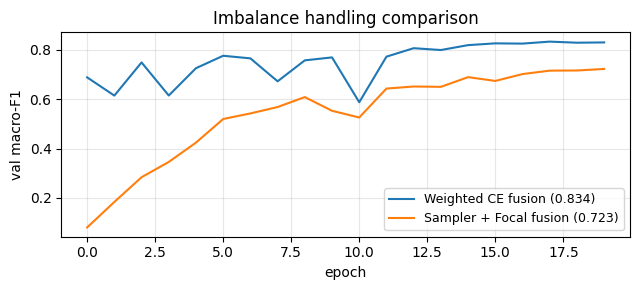

In [19]:
p_bal, trues = predict(fusion_bal, val_loader_fcnn, device=device)
print(classification_report(trues, p_bal, digits=3))

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(hist_fcnn, label=f'Weighted CE fusion ({max_f1:.3f})')
ax.plot(hist_bal, label=f'Sampler + Focal fusion ({bal_f1:.3f})')
ax.set_xlabel('epoch'); ax.set_ylabel('val macro-F1')
ax.legend(fontsize=9); ax.set_title('Imbalance handling comparison')
ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

stage_table['6 · Sampler+Focal fusion'] = bal_f1
print(pd.Series(stage_table).round(4))

# Cross-validation + Ensembling

In [20]:
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
EPOCHS_CV = 15  # trimmed from 20 — you're now training 5x as many models

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

X_full = train[feature_cols].values
y_full = train['label'].values
X_test_full = test[feature_cols].values

oof_preds = np.zeros(len(X_full), dtype=int)
test_probs_sum = np.zeros((len(X_test_full), 4))
fold_scores = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_full, y_full)):
    print(f'\n--- Fold {fold+1}/{N_FOLDS} ---')

    si_fold = SimpleImputer(strategy='median')
    X_tr_fold = si_fold.fit_transform(X_full[tr_idx])
    X_va_fold = si_fold.transform(X_full[va_idx])
    X_te_fold = si_fold.transform(X_test_full)

    sc_fold = StandardScaler()
    X_tr_fold = sc_fold.fit_transform(X_tr_fold)
    X_va_fold = sc_fold.transform(X_va_fold)
    X_te_fold = sc_fold.transform(X_te_fold)

    y_tr_fold = y_full[tr_idx]
    cc = np.bincount(y_tr_fold)
    cw = torch.tensor(len(y_tr_fold) / (len(cc) * cc), dtype=torch.float32).to(device)

    tr_loader = DataLoader(ECGDataset(X_tr_fold, y_tr_fold), batch_size=128, shuffle=True)
    va_loader = DataLoader(ECGDataset(X_va_fold, y_full[va_idx]), batch_size=256, shuffle=False)

    fold_model = FusionCNN(n_classes=4).to(device)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = torch.optim.AdamW(fold_model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, total_steps=EPOCHS_CV * len(tr_loader))

    train_model(epochs=EPOCHS_CV, model=fold_model, train_loader=tr_loader, val_loader=va_loader,
          optimizer=optimizer, scheduler=scheduler, criterion=criterion, device=device)

    fold_model.eval()
    with torch.no_grad():
        va_out = fold_model(torch.tensor(X_va_fold, dtype=torch.float32).to(device))
        oof_preds[va_idx] = va_out.argmax(dim=1).cpu().numpy()

        te_out = fold_model(torch.tensor(X_te_fold, dtype=torch.float32).to(device))
        test_probs_sum += torch.softmax(te_out, dim=1).cpu().numpy()

    fold_f1 = f1_score(y_full[va_idx], oof_preds[va_idx], average='macro')
    fold_scores.append(fold_f1)
    print(f'Fold {fold+1} Macro F1: {fold_f1:.4f}')

cv_f1 = f1_score(y_full, oof_preds, average='macro')
print(f'\nPer-fold scores: {[round(s,4) for s in fold_scores]}')
print(f'Mean fold F1: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})')
print(f'Out-of-fold Macro F1: {cv_f1:.4f}')


--- Fold 1/5 ---
epoch  1/15 | train loss 1.2304 | val Macro F1 0.6714
epoch  2/15 | train loss 0.5869 | val Macro F1 0.7479
epoch  3/15 | train loss 0.4041 | val Macro F1 0.6531
epoch  4/15 | train loss 0.3395 | val Macro F1 0.7326
epoch  5/15 | train loss 0.3201 | val Macro F1 0.5743
epoch  6/15 | train loss 0.2766 | val Macro F1 0.5370
epoch  7/15 | train loss 0.2485 | val Macro F1 0.7404
epoch  8/15 | train loss 0.2275 | val Macro F1 0.7568
epoch  9/15 | train loss 0.2005 | val Macro F1 0.7628
epoch 10/15 | train loss 0.1820 | val Macro F1 0.7521
epoch 11/15 | train loss 0.1680 | val Macro F1 0.7769
epoch 12/15 | train loss 0.1440 | val Macro F1 0.8084
epoch 13/15 | train loss 0.1306 | val Macro F1 0.8023
epoch 14/15 | train loss 0.1247 | val Macro F1 0.8090
epoch 15/15 | train loss 0.1185 | val Macro F1 0.8086
Training completed in 31s | Best Macro-F1: 0.8090
Fold 1 Macro F1: 0.8086

--- Fold 2/5 ---
epoch  1/15 | train loss 1.1987 | val Macro F1 0.6271
epoch  2/15 | train loss 0

# Submission

1 · dummy/most_frequent     0.1927
1 · dummy/stratified        0.2483
2 · LogReg (balanced)       0.7143
3 · MLP (from scratch)      0.8586
4 · 1D CNN                  0.8243
5 · CNN+RR fusion           0.8336
6 · Sampler+Focal fusion    0.7229
7 · 5-fold CV ensemble      0.8108
dtype: float64


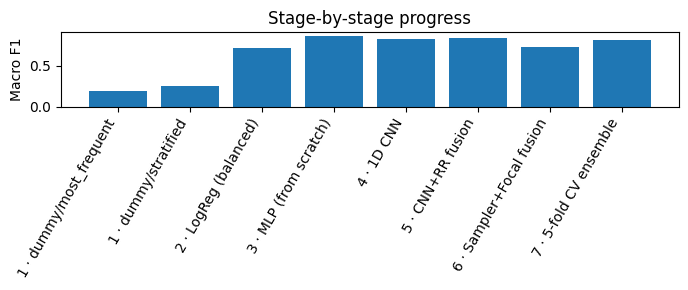

,id,label
0,te_0000000,2
1,te_0000001,0
2,te_0000002,0
3,te_0000003,0
4,te_0000004,0


In [21]:
final_test_pred = test_probs_sum.argmax(axis=1)  # soft-vote: average the 5 folds' probabilities

stage_table['7 · 5-fold CV ensemble'] = cv_f1
print(pd.Series(stage_table).round(4))

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(list(stage_table.keys()), list(stage_table.values()))
ax.set_ylabel('Macro F1')
ax.set_title('Stage-by-stage progress')
plt.xticks(rotation=60, ha='right')
plt.tight_layout(); plt.show()

submission = pd.DataFrame({'id': test['id'], 'label': final_test_pred})
submission.to_csv('submission.csv', index=False)
submission.head()